# TP: Régression logistique et `scikit-learn` 



Dans ce premier TP, nous mettons en oeuvre un modèle de **régression logistique** pour la prédiction de labels binaires $y \in \{0,1\}$. On rappelle que la régression logistique repose sur une modélisation probabiliste, et donc plutôt que de prédire simplement 0 ou 1, on construit un estimateur $\hat P(y=1|x)$ de la probabilité $\mathbf{P}(y=1|x)$ et on définit un classifieur comme
$$\hat y (x_{new}) = \begin{cases} 1 & \text{si } \hat P(y=1|x_{new}) \geq t, \\ 0 & \text{sinon}\end{cases}$$
pour un seuil $t\in(0,1)$ donné. Par défaut, si les labels jouent un rôle symmetrique, $t=1/2$.

# Le jeu de données

Les données utilisées dans ce TP proviennent d'un jeu de données classique qui s'appelle *Census Income dataset* (également connu sous le nom de *Adult Income* et disponible sur le site [https://archive.ics.uci.edu/ml/datasets/adult](https://archive.ics.uci.edu/ml/datasets/adult)).

Ce dataset a été extrait par Barry Becker du recensement américain de 1994 et est souvent utilisé pour des tâches de classification binaire, où l'objectif est de **prédire si un individu gagne plus ou moins de $50\,000$ dollars par an**, en se basant sur les caractéristiques démographiques et professionnelles disponibles. Les **caractéristiques sont qualitatives et quantitatives** et incluent l'âge, le niveau d'éducation, le statut matrimonial, la profession, le pays d'origine, le sexe, le capital investi, le nombre d'heures de travail par semaine, etc.

Le fichier `data/adult_clean.csv` a été obtenu en nettoyant les fichiers publics (voir le notebook `day1_preparation_data.ipynb`): on a retiré les données manquantes et les doublons. 

On utilise le module `pandas` qui est une bibliothèque open-source populaire en Python, largement utilisée pour la manipulation et l'analyse des données. Ce module fournit des structures de données flexibles et performantes: 
- les **DataFrames** qui sont similaires aux tables de base de données ou aux feuilles de calcul Excel
- les **Series** qui sont des tableaux unidimensionnels avec étiquettes.

In [1]:
import numpy as np
import pandas as pd

In [2]:
import warnings 
warnings.simplefilter(action='ignore', category=FutureWarning)

## Exercice : Chargement 

- Importer les données du fichier `data/adult_clean.csv` sous forme d'un `DataFrame` pandas que l'on nomme `dataset`. 
- Visualiser les premières lignes de `dataset`, noter le nombre de caractéristiques (et leurs noms) et le nom de la variable à prédire.
- Quel est le nombre total de données (de lignes) du `dataset`, et la proportion de données `<=50K` et `>50K`?

## Solution

In [3]:
# on visualise les premières lignes du fichier pour voir la structure
# ici le format est classique: la "," est le séparateur et la première ligne contient le nom des colonnes
filename = "data/adult_clean.csv"
with open(filename, 'r') as f:
    for line, k  in zip(f, range(5)): 
        print(line.strip())

age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K


In [4]:
# on crée l'objet dataset via l'appel de la fonction `read_csv` du module pandas
dataset = pd.read_csv(filename)

In [5]:
# on visualise les 5 premières lignes du `dataset`
dataset.head(5)

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
# on utilise la méthode `value_counts` pour obtenir des informations sur les données à prédire 
dataset["class"].value_counts()

class
<=50K    29265
>50K      9975
Name: count, dtype: int64

**Remarque** : Pour lister toutes les méthodes/attributs utilisables pour un objet on peut utiliser la fonction `dir` par exemple 
```python
print(dir(dataset))
```
Pour ne lister que les méthodes/attributs *publiques* on peut filtrer le résultat par exemple 
```python
print([m for m in dir(dataset) if m.startswith('_') == False])
```

In [7]:
print([m for m in dir(dataset) if m.startswith('_') == False])

['T', 'abs', 'add', 'add_prefix', 'add_suffix', 'age', 'agg', 'aggregate', 'align', 'all', 'any', 'apply', 'asfreq', 'asof', 'assign', 'astype', 'at', 'at_time', 'attrs', 'axes', 'between_time', 'bfill', 'boxplot', 'class', 'clip', 'columns', 'combine', 'combine_first', 'compare', 'convert_dtypes', 'copy', 'corr', 'corrwith', 'count', 'cov', 'cummax', 'cummin', 'cumprod', 'cumsum', 'describe', 'diff', 'div', 'divide', 'dot', 'drop', 'drop_duplicates', 'droplevel', 'dropna', 'dtypes', 'duplicated', 'education', 'empty', 'eq', 'equals', 'eval', 'ewm', 'expanding', 'explode', 'ffill', 'fillna', 'filter', 'first_valid_index', 'flags', 'floordiv', 'from_arrow', 'from_dict', 'from_records', 'ge', 'get', 'groupby', 'gt', 'head', 'hist', 'iat', 'idxmax', 'idxmin', 'iloc', 'index', 'infer_objects', 'info', 'insert', 'interpolate', 'isetitem', 'isin', 'isna', 'isnull', 'items', 'iterrows', 'itertuples', 'join', 'keys', 'kurt', 'kurtosis', 'last_valid_index', 'le', 'loc', 'lt', 'map', 'mask', 'ma

## Exercice : Exploration, visualisation 

Familiarisez-vous avec les données.

- Calculer quelques statistiques descriptives (à l'aide de `shape`, `dtypes`, `describe`, `value_counts`).
- Visualiser quelques caractéristiques en fonction des 2 groupes `<=50K` et `>50K`.

Pour tracer des graphiques on pourra utiliser les librairies `matplotlib` et `seaborn` :

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

On pourra utiliser les fonctions suivantes :
- `sns.scatterplot` pour des nuages des points
- `sns.histplot` pour des histogrammes et des diagrammes en bâtons

**Exemple** :

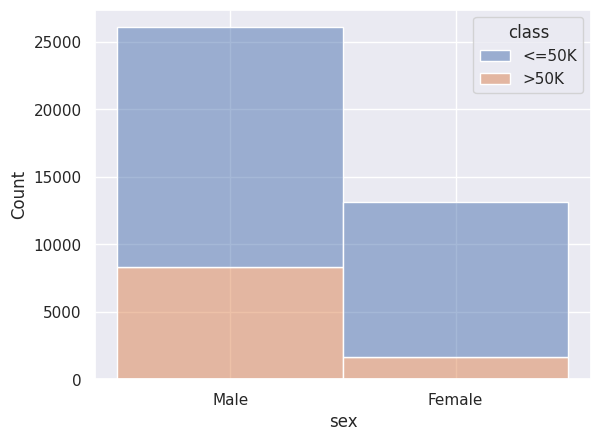

In [9]:
ax = sns.histplot(data=dataset, x="sex", hue="class", 
                  multiple="stack", alpha=0.5, discrete=True)

## Solution

In [10]:
dataset.shape

(39240, 13)

In [11]:
dataset.describe()

,age,capital-gain,capital-loss,hours-per-week
count,39240.000000,39240.000000,39240.000000,39240.000000
mean,39.309225,1253.314246,101.261340,41.206091
std,13.298041,7993.997264,431.434412,12.458021
min,17.000000,0.000000,0.000000,1.000000
25%,29.000000,0.000000,0.000000,40.000000
50%,38.000000,0.000000,0.000000,40.000000
75%,48.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


In [12]:
dataset.describe(include='str')

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,class
count,39240,39240,39240,39240,39240,39240,39240,39240,39240
unique,7,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,27717,12003,17947,5516,15645,33064,26097,35340,29265


In [13]:
dataset["sex"].value_counts()

sex
Male      26097
Female    13143
Name: count, dtype: int64

In [14]:
dataset["race"].value_counts()

race
White                 33064
Black                  4089
Asian-Pac-Islander     1299
Amer-Indian-Eskimo      435
Other                   353
Name: count, dtype: int64

In [15]:
dataset["workclass"].unique()

<StringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',     'Self-emp-inc',
      'Without-pay']
Length: 7, dtype: str

<Axes: xlabel='age', ylabel='Count'>

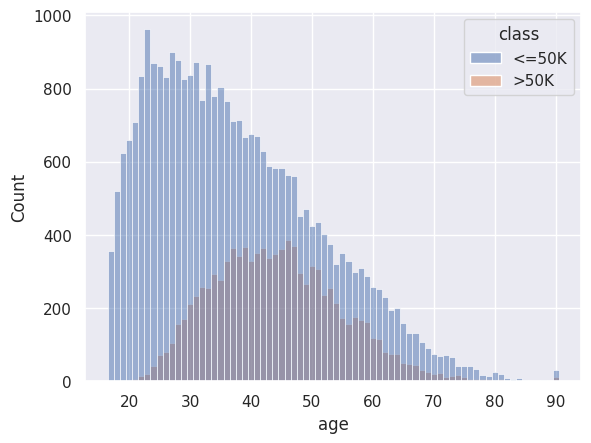

In [16]:
sns.histplot(data=dataset, x="age", 
             hue="class", 
             multiple="layer", 
             alpha=0.5, 
             discrete=True
            )

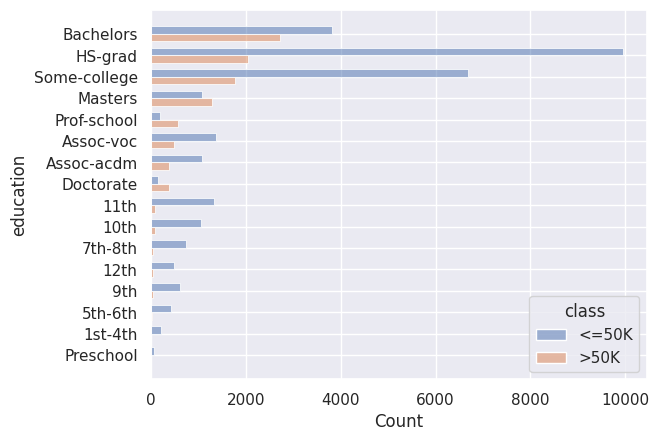

In [17]:
order = (
    dataset.loc[dataset["class"] == ">50K", "education"]
    .value_counts()
    .index
)

dataset["education"] = pd.Categorical(
    dataset["education"],
    categories=order,
    ordered=True
)

ax = sns.histplot(data=dataset, y="education", hue="class", 
                  multiple="dodge", shrink=0.7,
                  alpha=0.5, discrete=True)

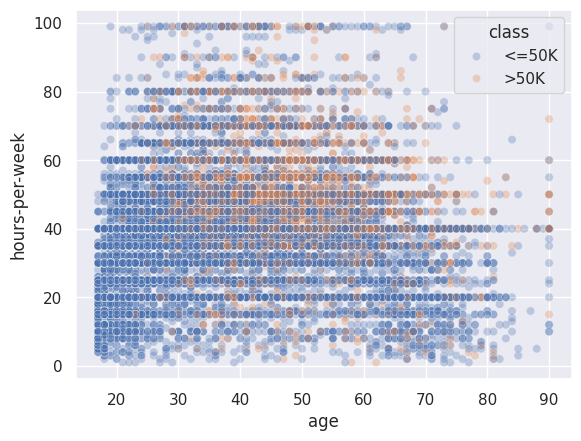

In [18]:
ax = sns.scatterplot(data=dataset, x="age", y="hours-per-week",
                     hue="class", alpha=0.3)

In [19]:
?sns.scatterplot

Signature:
sns.scatterplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    size=None,
    style=None,
    palette=None,
    hue_order=None,
    hue_norm=None,
    sizes=None,
    size_order=None,
    size_norm=None,
    markers=True,
    style_order=None,
    legend='auto',
    ax=None,
    **kwargs,
)
Docstring:
Draw a scatter plot with possibility of several semantic groupings.

The relationship between `x` and `y` can be shown for different subsets
of the data using the `hue`, `size`, and `style` parameters. These
parameters control what visual semantics are used to identify the different
subsets. It is possible to show up to three dimensions independently by
using all three semantic types, but this style of plot can be hard to
interpret and is often ineffective. Using redundant semantics (i.e. both
`hue` and `style` for the same variable) can be helpful for making
graphics more accessible.

See the :ref:`tutorial <relational_tutorial>` for more information.

The de

## Exercice : Pré-traitement des données

On ne travaille que très rarement sur des donnnées brutes. 

Pour des  **variables quantitatives**, il est important de les  **standardiser** (centrer et réduire) afin de les ramener à  des échelles comparables. Cela diminue également les problèmes numériques. 

Pour une **variable qualitative** ou **catégorielle**, il n'y a en général pas  d'ordre naturel de ses modalités. Donc il ne faut pas bêtement remplacer des catégories *A*, *B*, *C*,... par 1, 2, 3,... Le problème est que dans un modèle de régression, on va calculer par exemple des moyennes sur ces valeurs, mais en général *B* n'est pas la moyenne de *A* et *C* (alors que c'est le cas pour la valeur 2 par rapport à 1 et 3). Il nous faut alors un encodage qui est invariant à l'ordre des modalités. On utilise  le **one-hot encoding** qui consiste à transformer une variable qualitative en plusieurs variables binaires dites **dummies**. Une variable avec K modalités est transformée en K-1 variables binaires. Chacune de ces variables binaires indique pour une catégorie spécifiée si la variable observée est égale à cette catégorie ou pas. Il suffit de K-1 variables binaires pour encoder K catégories, car l'information sur la K-ième catégorie peut être déduite des K-1 autres variables binaires. Donc, si on utilisait K variables binaires, on introduirait des corrélations entre les colonnes, ce qu'il faut éviter dans un cadre de régression.

- Séparer les données en 3 dataframes qu'on nomme :

    - `quantitative`: dataframe avec toutes les covariables quantitatives
    - `qualitative`: dataframe avec toutes les covariables qualitatives
    - `category` : pour les labels observés `class`

En vue de la régression logistique on effectue le pré-traitement suivant: définir les variables 
- `labels` en remplaçant les classes `<=50K` et `>50K` par les valeurs numériques 0 et 1
- `quantitative_norm` obtenu en renormalisant le dataset `quantitative`
- `qualitative_enc` obtenu par l'appel de `get_dummies` du module `pandas` sur le dataset `qualitative`
- `standard_data` obtenu en regroupant `quantitative_norm` et `qualitative_enc`

## Solution

In [20]:
quant_columns = [ "age", "capital-gain", "capital-loss", "hours-per-week" ]
quali_columns = [ "workclass", "education", "marital-status", "occupation", 
                  "relationship", "race", "sex", "native-country" ]
quantitative = dataset[quant_columns]
qualitative = dataset[quali_columns]
category = dataset["class"]

**Remarque** :
On pourrait automatiser en utilisant par exemple 

```python
quantitative = dataset.columns[dataset.dtypes == 'int64']
qualitative = dataset.columns[dataset.dtypes == 'str'][:-1]
```

ou bien

```python
quantitative = dataset.describe().columns
qualitative = dataset.describe(include='str').columns[:-1]
```

In [21]:
labels = category.map({ '<=50K': 0, '>50K': 1 }) 

In [22]:
quantitative_norm = (quantitative - quantitative.mean()) / quantitative.std()
quantitative_norm.describe()

,age,capital-gain,capital-loss,hours-per-week
count,3.924000e+04,3.924000e+04,3.924000e+04,3.924000e+04
mean,1.448609e-16,7.243045e-18,-2.100483e-17,4.345827e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.677632e+00,-1.567819e-01,-2.347085e-01,-3.227326e+00
25%,-7.752439e-01,-1.567819e-01,-2.347085e-01,-9.681239e-02
50%,-9.845249e-02,-1.567819e-01,-2.347085e-01,-9.681239e-02
75%,6.535380e-01,-1.567819e-01,-2.347085e-01,3.045355e-01
max,3.811898e+00,1.235248e+01,9.861844e+00,4.639092e+00


In [23]:
qualitative_enc = pd.get_dummies(qualitative)
qualitative_enc.describe()

,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_Bachelors,education_HS-grad,education_Some-college,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
count,39240,39240,39240,39240,39240,39240,39240,39240,39240,39240,...,39240,39240,39240,39240,39240,39240,39240,39240,39240,39240
unique,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
top,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
freq,37869,36265,27717,37645,35571,37348,39219,32718,27237,30783,...,39178,39065,39220,39139,39185,39211,39214,35340,39157,39217


In [24]:
standard_data = pd.concat([quantitative_norm, qualitative_enc], axis=1)

**Remarque 1**: 
La valeur 98 correspond à la somme des valeurs possibles par covariable qualitative. On peut le vérifier aisément:
```python
counter = 0
for col in qualitative:
    print(col, dataset[col].unique().shape[0])
    counter += dataset[col].unique().shape[0]
print(counter)
```


**Remarque 2**:
On pourrait utiliser les fonctions `StandardScaler` et `OneHotEncoder` du module `scikit-learn` mais l'usage est d'utiliser ces fonctions à travers un pipeline pour automatiser le processus. On verra l'utilisation un peu plus loin. 

Si vous executez les lignes suivantes, vous remarquerez que `quantitative_norm2` est un tableau `numpy` (il a perdu sa structure de données de `DataFrame`) et `qualitative_enc2` est une matrice creuse (sparse matrix) de `scipy`. 
```python
from sklearn.preprocessing import OneHotEncoder, StandardScaler

quantitative_preprocessor = StandardScaler()
qualitative_preprocessor = OneHotEncoder()

quantitative_norm2 = quantitative_preprocessor.fit_transform(quantitative)
qualitative_enc2 = qualitative_preprocessor.fit_transform(qualitative)
```

Si on reconstruit des `DataFrame` à partir de ces tableaux numériques on peut vérifier que ces fonctions donnent des sorties similaires à notre traitement manuel:
```python
np.sum((quantitative_norm - pd.DataFrame(quantitative_norm2, columns=quantitative.columns))**2)
qualitative_enc.equals(
    pd.DataFrame(qualitative_enc2.todense().astype(bool), columns=qualitative_enc.columns)
)
```

**Attention**:
On normalise et on encode sur l'ensemble des données! 

# Régression logistique

Le but de ce TP est de fitter un modèle de régression logistique à ces données afin de prédire le label (0 pour `<=50K` ou 1 pour `>50K`) pour des  nouveaux individus à partir de leurs caractéristiques. Nous commençons par le modèle simple qui prend en compte toutes les variables.


## Exercice : Définition du modèle et estimation

- Utiliser la fonction `LogisticRegression` de `sklearn.linear_model` pour effectuer une régression logistique simple (i.e. sans pénalisation). L'estimation des paramètres se fait avec la fonction `fit`.
- Visualiser les coefficients estimés (intercept et variables).

## Solution

In [25]:
from sklearn.linear_model import LogisticRegression
?LogisticRegression

Init signature:
LogisticRegression(
    penalty='deprecated',
    *,
    C=1.0,
    l1_ratio=0.0,
    dual=False,
    tol=0.0001,
    fit_intercept=True,
    intercept_scaling=1,
    class_weight=None,
    random_state=None,
    solver='lbfgs',
    max_iter=100,
    verbose=0,
    warm_start=False,
    n_jobs=None,
)
Docstring:     
Logistic Regression (aka logit, MaxEnt) classifier.

This class implements regularized logistic regression using a set of available
solvers. **Note that regularization is applied by default**. It can handle both
dense and sparse input `X`. Use C-ordered arrays or CSR matrices containing 64-bit
floats for optimal performance; any other input format will be converted (and
copied).

The solvers 'lbfgs', 'newton-cg', 'newton-cholesky' and 'sag' support only L2
regularization with primal formulation, or no regularization. The 'liblinear'
solver supports both L1 and L2 regularization (but not both, i.e. elastic-net),
with a dual formulation only for the L2 penalt

In [26]:
from sklearn.linear_model import LogisticRegression

# Définition du modèle de régression logistique : sans pénalisation 
model = LogisticRegression(penalty=None, max_iter=1000)
# sans l'option max_iter, on peut avoir un nb max d'itérations insuffisant pour atteindre la convergence

# On estime les paramètres de ce modèle sur les données 
model.fit(standard_data, labels)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [27]:
print([m for m in dir(model) if m.startswith('_') == False])

['C', 'class_weight', 'classes_', 'coef_', 'decision_function', 'densify', 'dual', 'feature_names_in_', 'fit', 'fit_intercept', 'get_metadata_routing', 'get_params', 'intercept_', 'intercept_scaling', 'l1_ratio', 'max_iter', 'n_features_in_', 'n_iter_', 'n_jobs', 'penalty', 'predict', 'predict_log_proba', 'predict_proba', 'random_state', 'score', 'set_fit_request', 'set_params', 'set_score_request', 'solver', 'sparsify', 'tol', 'verbose', 'warm_start']


In [28]:
# Résultats de la régression logistique
# On visualise l'intercept b et les 102 coefficients w_i estimés pour les 102 variables 
print("intercept:", model.intercept_)
print("coefficients:", model.coef_.shape, "\n", model.coef_)

intercept: [-1.41321978]
coefficients: (1, 102) 
 [[ 0.27797997  2.49716074  0.27604279  0.34343342  0.38469291 -0.19085749
  -0.08780939  0.09593784 -0.56863132 -0.33373514 -0.7128172   1.00178119
  -0.01467199  0.31043911  1.34463367  1.96593024  0.42265362  0.49629919
   1.91131144 -0.74564125 -0.89365331 -1.2943084  -0.41176509 -1.08819933
  -1.00486861 -1.57027944 -1.84288083 -0.87102498  1.80557794  1.36083139
  -0.73358158 -1.24765632 -0.94593401 -0.78143222  0.05463881  0.08777447
   0.11834535  0.76978701 -0.92327859 -0.59007708 -0.1705299  -0.81783712
  -1.84693022  0.53347137  0.48649024  0.2916639   0.57317509  0.02008689
  -0.37599109  0.15788785 -0.90744018 -0.95333954 -0.0321442   0.69780737
  -0.75088318  0.18513054 -0.38328177 -0.29012604 -0.17405934 -1.04343041
  -0.36978937  0.85381277  0.73928784 -0.50141092 -1.94795331  0.48812061
  -0.91615449 -0.21070241 -0.40751035  0.70262927  1.04214401  0.37800006
   0.07154842 -0.36235547  0.45339706 -0.0129221   0.04333817 

## Exercice : Prédiction

La méthode `predict_proba` renvoie 2 colonnes: la première est la probabilité, conditionnellement aux caractéristiques de chaque individu, d'être dans la catégorie `<50K` (label 0, négatif) et la seconde la probabilité, conditionnellement aux caractéristiques de chaque individu, d'être dans la catégorie  `>=50K` (label 1, positif). A partir de ces probabilités on peut "décider" en fixant un seuil $t \in [0,1]$ d'être ou non dans une des 2 catégories en utilisant le classifieur construit à partir de ces probabilités : 
$$\hat y (x_{new}) = \begin{cases} 1 & \text{si } \hat P(y=1|x_{new}) \geq t, \\ 0 & \text{sinon}\end{cases}$$

- Calculer $\hat P(y=1|x)$, les probabilités que `>50K` pour chaque individu $x$ (`predict_proba()`) et les prédictions $\hat y(x)$ (`predict()`) que l'on obtient par seuillage des probabilités au seuil de $t = 1/2$.
- Comparer le nombre moyen de positifs prédits par rapport à celui connu dans `labels`. 
- Visualiser la distribution des probabilités prédites.
- Faire varier le seuil $t \in [0,1]$.

## Solution

In [29]:
seuil_t = 0.5   # à modifier pour voir l'influence de ce paramètre 
pred_prob = model.predict_proba(standard_data)
pred_t = pred_prob[:, 1] > seuil_t  # ce vecteur de booléen est la prédiction obtenue avec le seuil t 
print(f"La proportion de positifs >=50K prédits avec le seuil t={seuil_t} est:", pred_t.mean())

La proportion de positifs >=50K prédits avec le seuil t=0.5 est: 0.21009174311926607


La méthode `predict` renvoie directement la prédiction obtenue avec le seuil $t = 0.5$. 

In [30]:
pred = model.predict(standard_data)
print(f"La proportion de positifs >=50K prédits par le modèle est:", pred.mean())

La proportion de positifs >=50K prédits par le modèle est: 0.21009174311926607


In [31]:
print("La proportion de positifs >=50K dans labels est:", np.mean(labels.to_numpy()))

La proportion de positifs >=50K dans labels est: 0.25420489296636084


<Axes: xlabel='probRegLog', ylabel='Count'>

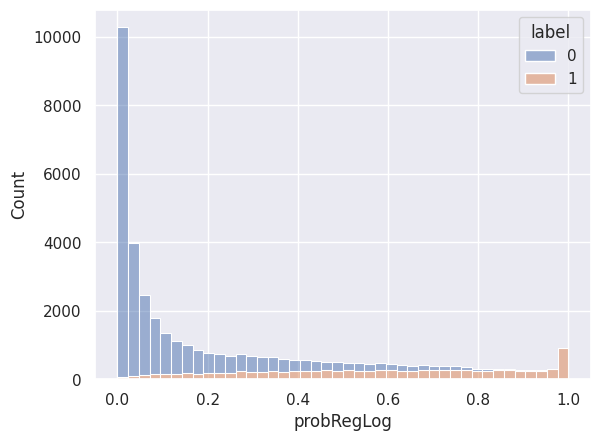

In [32]:
dfPredTest = pd.DataFrame({'label': labels, 
                           'probRegLog': model.predict_proba(standard_data)[:,1]})
sns.histplot(data=dfPredTest, x="probRegLog", hue="label", 
             multiple="stack", alpha=0.5, discrete=False)

# Echantillons : apprentissage et test 

Utiliser l'intégralité du jeu de données pour entrainer le modèle comme nous l'avons fait n'est pas la bonne démarche à suivre, puisque nous avons testé le modèle sur les mêmes données qui l'ont entrainé, alors qu'il faudrait le tester sur des nouvelles données. 

C'est pour cela qu'il faut séparer le jeu de données en deux, un jeu d'apprentissage (TRAIN) et un de test (TEST).

On rappelle que la modélisation se fait en trois temps :
- on sépare les données : TRAIN / TEST
- on apprend le modèle sur TRAIN
- on évalue la performance du modèle appris sur TEST

On coupe les données de façon aléatoire en deux groupes. 
Le plus souvent, on les sépare en 80% pour l'apprentissage et 20% pour le test. D'autres pourcentages courants sont 67-33 ou 50-50.
On   utilise la  fonction `train_test_split` du package `sklearn.model_selection` pour séparer aléatoirement les données. 

Même si le split est aléatoire, on souhaite que les deux échantillons soient tous les deux représentatifs du problème. En particulier, on voudrait qu'ils contiennent le même pourcentage de labels 0 et 1, ce qui est notamment important quand  les labels ne sont pas équilibrés (pas 50-50).

Ici, la proportion de 1 (individus qui sont dans la catégorie `>50K`) est d'environ 0.25 (le vérifier!).

Si le taux n'est pas très élevé, une coupe totalement aléatoire des données risque de produire des sous-échantillons où l'un des deux ne contient que peu de labels qui valent 1. Cela peut être problématique pour l'apprentissage du modèle comme pour l'évaluation de la méthode.

En pratique, dans des problèmes de classification, on force alors la même répartition des labels dans les deux échantillons TRAIN et TEST, via l'option `stratify`.

## Exercice : Création des échantillons 

Utiliser la fonction `train_test_split` du module `scikit-learn` pour créer à partir de nos données `quantitative_norm`, `qualitative_enc` et `labels` les 4 variables suivantes: 
- `x_train` et `y_train` qui contiennent 80% du jeu de données pour l'apprentissage du modèle de régression logistique 
- `x_test` et `y_test` qui contiennent les 20% restants pour le test.

## Solution

In [33]:
from sklearn.model_selection import train_test_split

# split TRAIN / TEST
x_train, x_test, y_train, y_test = train_test_split(
    pd.concat([quantitative_norm, qualitative_enc], axis=1),
    labels,
    stratify=labels,
    test_size = 0.2,
    random_state = 42
)

In [34]:
y_train

15953    1
9481     0
17241    0
8509     1
9544     1
        ..
30787    0
10929    0
26651    1
22558    1
8007     0
Name: class, Length: 31392, dtype: int64

On vérifie que `y_train` et `y_test` contiennent la même proportion de 1 que `labels` :

In [35]:
print(np.mean(labels), np.mean(y_train), np.mean(y_test))

0.25420489296636084 0.25420489296636084 0.25420489296636084


**Remarque**:
Dans cette première approche nous utilisons la fonction `train_test_split` du module `scikit-learn`. En pratique il est préférable d'utiliser une approche par validation croisée qui permet d'évaluer la performance de généralisation du modèle. 

# Régression logistique avec séparation des données en train et test

Reprendre la regression logistique vue au point précédent, avec les bons jeu de données pour l'entrainement et le test.

## Exercice : Création du modèle et estimation

- Utiliser la fonction `LogisticRegression` de `sklearn.linear_model` pour effectuer une régression logistique simple (i.e. sans pénalisation). Fitter le modèle sur les données `train`. 
- Visualiser les coefficients estimés (intercept et variables).

## Solution

In [36]:
from sklearn.linear_model import LogisticRegression

# Définition du modèle de régression logistique : sans pénalisation 
model = LogisticRegression(penalty=None, max_iter=1000)
# sans l'option max_iter, on peut avoir un nb max d'itérations insuffisant pour atteindre la convergence
# On estime les paramètres de ce modèle sur les données 
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [37]:
print([m for m in dir(model) if m.startswith('_') == False])

['C', 'class_weight', 'classes_', 'coef_', 'decision_function', 'densify', 'dual', 'feature_names_in_', 'fit', 'fit_intercept', 'get_metadata_routing', 'get_params', 'intercept_', 'intercept_scaling', 'l1_ratio', 'max_iter', 'n_features_in_', 'n_iter_', 'n_jobs', 'penalty', 'predict', 'predict_log_proba', 'predict_proba', 'random_state', 'score', 'set_fit_request', 'set_params', 'set_score_request', 'solver', 'sparsify', 'tol', 'verbose', 'warm_start']


In [38]:
# Résultats de la régression logistique
# On visualise l'intercept b et les 102 coefficients w_i estimés pour les 102 variables 
print("intercept:", model.intercept_)
print("coefficients:", model.coef_.shape, "\n", model.coef_)

intercept: [-1.42355028]
coefficients: (1, 102) 
 [[ 0.29258086  2.4849235   0.28240143  0.35447637  0.39707521 -0.22468566
  -0.13715375  0.00699718 -0.56657604 -0.36437757 -0.53482965  0.99220473
  -0.03107011  0.31618131  1.33054289  1.94483036  0.37064021  0.50302545
   1.92607486 -0.71990081 -1.0143648  -1.46141963 -0.22265402 -1.23619586
  -1.010226   -1.24444305 -1.86677581 -0.90987968  2.00215295  1.50572799
  -0.88626029 -1.3000213  -0.95136692 -0.88390305  0.0830238  -0.16762032
   0.1951756   0.80934782 -0.82200622 -0.47050349 -0.10723922 -0.81020137
  -2.16361215  0.55167572  0.47716145  0.31437557  0.64623518  0.04063735
  -0.46559433  0.26002418 -1.08572739 -0.80483763  0.02506813  0.64751676
  -0.79579608  0.23327954 -0.37538198 -0.27387801 -0.21177375 -1.04130554
  -0.38224474  0.78622321  0.76135979 -0.54677231 -2.31858031  0.43704548
  -0.6094765  -0.51759476 -0.92846873  0.60039168  0.97250184  0.36289955
   0.31147644 -0.27921028  0.645029   -0.01484648  0.07535237 

## Exercice : Prédiction

- Sur le jeu `test`, calculer $\hat P(y=1|x)$, les probabilités que `>50K` pour chaque individu $x$ (`predict_proba()`) et les prédictions $\hat y(x)$ (`predict()`) que l'on obtient par seuillage des probabilités au seuil de $t = 1/2$.
- Comparer le nombre moyen de positifs prédits par rapport à celui connu dans `y_test`. 
- Visualiser la distribution des probabilités prédites.
- Faire varier le seuil $t \in [0,1]$.

## Solution

In [39]:
seuil_t = 0.5   # à modifier pour voir l'influence de ce paramètre 
pred_prob = model.predict_proba(x_test)
pred_t = pred_prob[:, 1] > seuil_t  # ce vecteur de booléen est la prédiction obtenue avec le seuil t 
print(f"La proportion de positifs >=50K prédits avec le seuil t={seuil_t} est:", pred_t.mean())

La proportion de positifs >=50K prédits avec le seuil t=0.5 est: 0.21444954128440366


La méthode `predict` renvoie directement la prédiction obtenue avec le seuil $t = 0.5$. 

In [40]:
pred = model.predict(x_test)
print(f"La proportion de positifs >=50K prédits par le modèle est:", pred.mean())

La proportion de positifs >=50K prédits par le modèle est: 0.21444954128440366


In [41]:
print("La proportion de positifs >=50K dans y_test est:", np.mean(y_test.to_numpy()))

La proportion de positifs >=50K dans y_test est: 0.25420489296636084


<Axes: xlabel='probRegLog', ylabel='Count'>

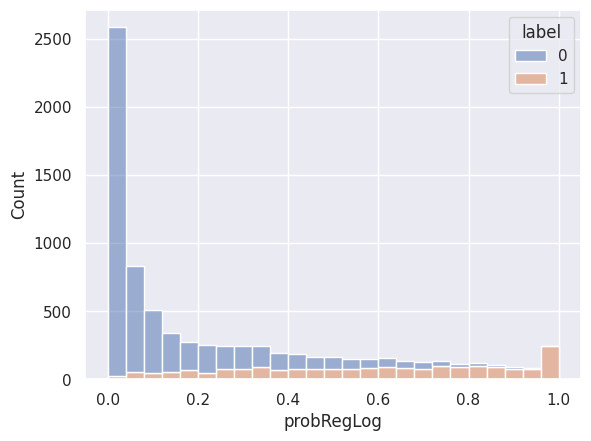

In [42]:
dfPredTest = pd.DataFrame({'label': y_test, 
                           'probRegLog': model.predict_proba(x_test)[:,1]})
sns.histplot(data=dfPredTest, x="probRegLog", hue="label", 
             multiple="stack", alpha=0.5, discrete=False)

# Mesures de qualité du classifieur 

Le module `metrics` de `scikit-learn` contient plusieurs fonctions qui permettent d'évaluer la qualité des prédictions d'un modèle. Ces métriques sont détaillées dans les sections sur les métriques de classification, les métriques de classement multi-label, les métriques de régression et les métriques de clustering.

In [43]:
import sklearn.metrics as metrics
print(dir(metrics))

['ConfusionMatrixDisplay', 'DetCurveDisplay', 'DistanceMetric', 'PrecisionRecallDisplay', 'PredictionErrorDisplay', 'RocCurveDisplay', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_base', '_classification', '_dist_metrics', '_pairwise_distances_reduction', '_pairwise_fast', '_plot', '_ranking', '_regression', '_scorer', 'accuracy_score', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'auc', 'average_precision_score', 'balanced_accuracy_score', 'brier_score_loss', 'calinski_harabasz_score', 'check_scoring', 'class_likelihood_ratios', 'classification_report', 'cluster', 'cohen_kappa_score', 'completeness_score', 'confusion_matrix', 'confusion_matrix_at_thresholds', 'consensus_score', 'coverage_error', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'd2_pinball_score', 'd2_tweedie_score', 'davies_bouldin_score', 'dcg_score', 'det_curve', 'euclidean_distances', 'explained_variance_s

## Erreurs de classification 
Pour chaque individu $i$ de caractéristiques $x_i$ dans l'échantillon, nous avons : 
- un vrai label/valeur $y_i$
- un label/valeur prédit $\hat y_i$

Deux types d'erreur peuvent se produire :
1. Prédire $\hat y_i =1$ alors que $y_i=0$ (faux positif/false positive, FP)
2. Prédire $\hat y_i =0$ alors que $y_i=1$ (faux négatif, false negative, FN)

Dans un contexte pratique, ces deux erreurs ne sont pas symétriques, parce qu'une erreur peut porter à des  effets plus négatifs que l'autre. En général, les labels sont choisis de sorte à être moins tolérants aux faux positifs qu'aux faux négatifs, pensons par exemple aux tests de grossesse, ou aux procès en justice. 


### Exercice : Accuracy score (ou taux de bonnes classifications)

Le taux de bonnes classifications (_accuracy score_) est la mesure de performance qui représente la proportion d'observations correctement classées par le modèle parmi l'ensemble total des observations. Ce taux est un pourcentage, où une valeur de 100% signifie que toutes les prédictions du modèle sont correctes.

- Implémenter à la main (en `numpy`) le calcul de ce score pour les données de test.
- Obtenir ce score via l'appel de `accuracy_score` du module `sklearn.metrics` et via la méthode `score` de l'objet `model`.
- Comparer ce score à un estimateur trivial qui consiste à toujours renvoyer la classe la plus fréquente.

### Solution

In [44]:
# accuracy calculé à la main
y_predicted = model.predict(x_test)
accuracy = np.mean(y_predicted == y_test)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.841


In [45]:
# accuracy avec sklearn.metrics
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_predicted)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.841


In [46]:
# accuracy avec score
print(f"Accuracy: {model.score(x_test, y_test):.3f}")

Accuracy: 0.841


Comme la proportion de personnes dans la classe `<=50K` est d'environ 75%, un  classifieur trivial consiste à décider de prédire toujours `<=50K` quelque soit les valeurs des variables. L'accuracy de ce classifieur est alors de 75% :

In [47]:
dummy_accuracy = np.mean(np.zeros_like(y_test) == y_test)
print(f"Accuracy of the dummy classifier: {dummy_accuracy:.3f}")

Accuracy of the dummy classifier: 0.746


In [48]:
from sklearn.dummy import DummyClassifier

dummy_classifier = DummyClassifier(strategy="most_frequent")
dummy_classifier.fit(x_train, y_train)
print(f"Accuracy of the dummy classifier: {dummy_classifier.score(x_test, y_test):.3f}")

Accuracy of the dummy classifier: 0.746


Il est alors important de noter qu'un classifieur trivial peut déjà avoir une accuracy assez élevée ! 
Et du coup, dans notre cas, une accuracy de 84% est   moins impressionnante qu'à première vue.
Il faut alors toujours comparer l'accuracy d'un classifieur à celle d'une méthode baseline. 

## Matrice de confusion, recall, precision

La matrice de confusion permet de visualiser les performances du modèle en termes de prédictions correctes (vrais positifs et vrais négatifs) et d'erreurs de prédiction (faux positifs et faux négatifs). La représentation classique se fait sous forme d'une matrice où les nombres sur la diagonale sont liés aux prédictions correctes, tandis que les nombres hors de la diagonale sont liés aux prédictions incorrectes. 

![](img/confusion-matrix-python.jpg)

Plus précisément: 

- TP = **true positive** : les personnes de la classe `>50K` prédites comme telles par le modèle 
- TN = **true negative** : les personnes de la classe `<=50K` prédites comme telles par le modèle 
- FP = **false positive** : les personnes de la classe `<=50K` prédites comme étant `>50K`
- FN = **false negative** : les personnes de la classe `>50K` prédites comme étant `<=50K`

**Attention**:
Dans la page wikipedia la matrice est "inversée": les vrais positifs sont en haut à gauche... 

A partir de ces données on peut construire plusieurs indicateurs de performance, dont le recall et la précision.

### Recall ou sensitivity ou sensibilité

$$\frac{\text{TP}}{\text{\# (real P)}} = \frac{\text{TP}}{\text{TP+FN}}$$
Mesure la capacité du classifieur à identifier tous les exemples positifs réels, c'est-à-dire sa sensibilité ou son taux de détection. Dans notre cadre, le recall est le taux d'individus identifiés comme `>50K` par le classifeur parmi tous les individus avec `>50K` dans `y_test`.

### Precision
$$\frac{\text{TP}}{\text{\# (predicted P)}} = \frac{\text{TP}}{\text{TP+FP}}$$
Mesure la capacité du classifieur à ne prédire positif que lorsque la prédiction est vraiment correcte.  P. ex.  le classifieur qui prédit systématiquement `>50K` pour tous les individus a un  recall  de 100%, mais sa precision est de 25%. 

Dans l'idéal  les deux scores,  recall et  precision, devraient être élevés.



### Exercice : Matrice de confusion


- Tracer la matrice de confusion en utilisant `ConfusionMatrixDisplay` et donner les scores `recall` et `precision`.

### Solution

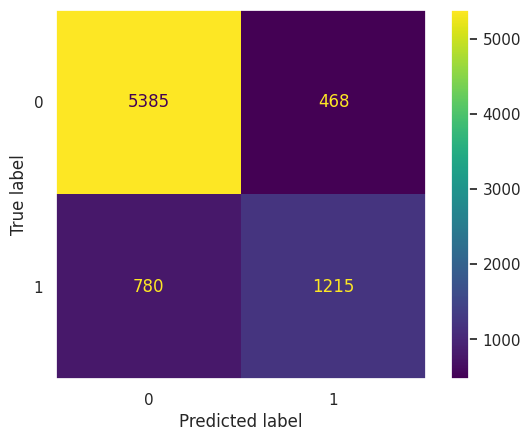

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, x_test, y_test)
plt.grid(False)

In [50]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_predicted)
recall = recall_score(y_test, y_predicted)

print(f"Precision score: {precision:.3f}")
print(f"Recall score: {recall:.3f}")

Precision score: 0.722
Recall score: 0.609


## Courbe ROC, AUC

Les valeurs prédites `y_predicted` ci-dessus ont été obtenues en seuillant les probabilités de `>50K` calculées par le modèle de régression logistique avec le seuil par defaut $t=1/2$.

$$\hat y_t (x_{new}) = \begin{cases} 1 & \mathbf{\hat P}(y=1 | x_{new}) \geq t, \\ 0 & \text{sinon.}\end{cases}$$

Or, en variant le seuil $t\in(0,1)$ il est possible que le classifieur associé ait des meilleurs scores.

La courbe ROC (Receiver Operating Characteristic) est une courbe paramétrique, paramétrée par $t \in [0,1]$. Elle représente les points $(\text{FPR}_t, \text{TPR}_t)$ pour tout seuil $t\in[0,1]$, où 

- $\text{TPR}_t$ (True positive rate) est le recall en fonction du seuil $t$ :
$$\frac{\text{TP}_t}{\text{TP}_t+\text{FN}_t}$$

- $\text{FPR}_t$ (False positive rate) est définit par le ratio suivant en fonction du seuil $t$ :
$$\frac{\text{FP}_t}{\text{FP}_t+\text{TN}_t}$$

Avec le seuil $t=1$, le classifieur prédit `<=50K` systématiquement, donc il n'y a pas de positifs et on a $\text{TP}_1 = 0$ et $\text{FP}_1 = 0$. En revanche, avec un seuil de $t=0$, le classifieur prédit toujours `>50K` et donc on a $\text{TP}_0 = 1$ et $\text{FP}_0 = 1$. Toutes les courbes ROC commencent donc au point $(0, 0)$ et se terminent au point $(1,1)$. La fonction $y=x$ represente la courbe ROC de la famille di classifieurs $\hat y_t (x_{new}) = 1$ avec probabilité $t\in(0,1)$.

Si la courbe est élevée, le modèle a une très bonne performance quelque soit le seuil. Cela est mesuré par l'aire sous la courbe (AUC -- Area Under the ROC curve). L'AUC permet de comparer deux modèles, ou un modèle sur des jeux de données différentes, comme les données train et test.

### Exercice : ROC
- Utiliser la fonction `RocCurveDisplay` pour tracer la courbe ROC de notre modèle pour les données train et les données test. Sur quelles données observe-t-on une meilleure performance ?
- Utiliser la fonction `roc_auc_score` pour calculer l'AUC sur les données de test et vérifier qu'elle correspond à l'AUC indiquée sur le tracé de courbe au point précédent.

### Solution

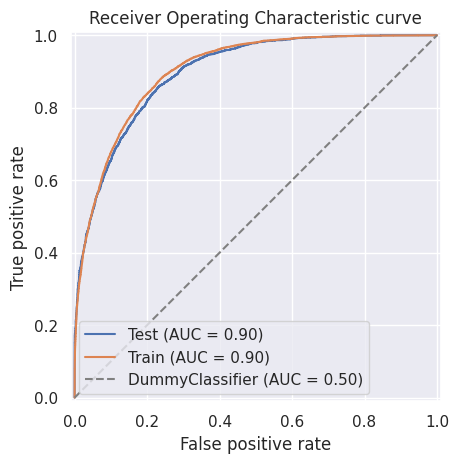

In [51]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots()
RocCurveDisplay.from_estimator(model, x_test, y_test, name="Test", ax=ax)
RocCurveDisplay.from_estimator(model, x_train, y_train, name="Train", ax=ax)
RocCurveDisplay.from_estimator(dummy_classifier, x_test, y_test, linestyle="--", color='grey', ax=ax)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Receiver Operating Characteristic curve")
ax.legend()
plt.show()

In [52]:
from sklearn.metrics import roc_auc_score
hat_p = model.predict_proba(x_test)
AUC_noPenalty = roc_auc_score( y_test, hat_p[:,1])
print(f"AUC no penalty: {AUC_noPenalty:.5f}")

AUC no penalty: 0.89819


## Courbe precision/recall, AP

Un autre outil de comparaison est la courbe precision/recall qui représente les points des coordonnées (recall, precision) pour tout seuil $t\in[0,1]$. L'interprétation est la même : plus la courbe est élevée (ou plus l'aire sous la courbe est grande), mieux c'est.

Noter que contrairement à la courbe ROC, la courbe precision/recall n'est pas toujours monotone.

### Exercice : precision/recall
- Tracer la courbe precision/recall de notre modèle sur les données test en utilisant la fonction `PrecisionRecallDisplay`.


### Solution

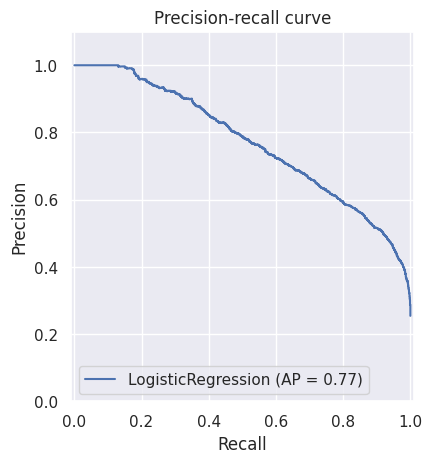

In [53]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots()
PrecisionRecallDisplay.from_estimator(model, x_test, y_test, ax=ax)
#PrecisionRecallDisplay.from_estimator(dummy_classifier, x_test, y_test, linestyle="--", ax=ax)
# il n'est pas recommandé de tracer la courbe du dummy_classifier car l'interprétation est douteuse...
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1.1)
ax.set_title("Precision-recall curve")
ax.legend()
plt.show()

# Régression logistique avec pénalisations

Une pénalité est une fonction $\text{pen}(w)$ qui prend des grandes valeurs pour des grandes valeurs de $w$. 

Pour éviter le phénomène du *overfitting*, nous cherchons à minimiser non plus une fonction de perte $L (w, b)$, mais une fonction de perte pénalisé :

$$ L (w, b) + \frac 1 C \; \text{pen}(w)$$

Plus la constante $C$ est petite, plus le modèle est pénalisé. Une constante $C=\infty$ correspond à une absence de pénalité.

## Régression ridge

Nous allons utiliser une pénalité en norme 2 (dite $\ell_2$ ou Ridge) sur les coefficients de la régression. 

$$\text{pen}(w) =\| w\|_2^2  = \sum_{k=1}^d w_k^2$$

Cette pénalité Ridge a tendance à "rétrecir" les valeurs des coefficients (on parle de shrinkage) et régularise la solution.

### Exercice : pénalité $\ell_2$

- Mettre en oeuvre la régression logistique avec pénalité $\ell_2$ sur les données d'apprentissage. On utilisera toujours la fonction `LogisticRegression`avec  l'option `l1_ratio=0`. On utilisera une pénalité assez forte, p. ex. `C=0.01`. 
- Comparer les valeurs des coefficients avec le cas sans pénalité (visualisez l'effet de shrinkage). 
- Évaluer les performances du classifieur sur les données de test.
- Pour les deux classifieurs (avec et sans pénalisation $\ell_2$), comparer les courbes de score sur les données `test` ainsi que les performances en termes de courbes (ROC ou precision-recall) et d'AUC. 

### Solution

In [54]:
# On définit le modèle avec une pénalité ridge et un C=0.01
C_ridge = 0.01
model_ridge = LogisticRegression(l1_ratio=0, C=C_ridge, max_iter=1000, solver='liblinear')

# On entraine le modèle
model_ridge.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [55]:
# On définit une fct pour extraire les coefficients
def extract_coeff(model, name=None):
    return pd.DataFrame({ 
        "feature": model.feature_names_in_, 
        "value": np.abs(model.coef_.flatten()), 
        "method": name, 
    })

In [56]:
extract_coeff(model, "no penality")

,feature,value,method
0,age,0.292581,no penality
1,capital-gain,2.484924,no penality
2,capital-loss,0.282401,no penality
3,hours-per-week,0.354476,no penality
4,workclass_Federal-gov,0.397075,no penality
...,...,...,...
97,native-country_Thailand,0.631879,no penality
98,native-country_Trinadad&Tobago,0.789213,no penality
99,native-country_United-States,0.381446,no penality
100,native-country_Vietnam,1.703164,no penality


In [57]:
# On affiche le nombre de coefficients non nuls 
print(f"Nombre de coefficients non nuls avec pénalité Ridge (C={C_ridge}):", np.sum(extract_coeff(model_ridge)["value"] > 0))

Nombre de coefficients non nuls avec pénalité Ridge (C=0.01): 102


In [58]:
# On trie les coefficients par ordre decroissant et on selectionne les premiers 20
df1 = extract_coeff(model, "no penality").sort_values("value", ascending=False)[:20]
df2 = extract_coeff(model_ridge, f"ridge C={C_ridge}")
df2 = df2[df2["feature"].isin(df1["feature"])]

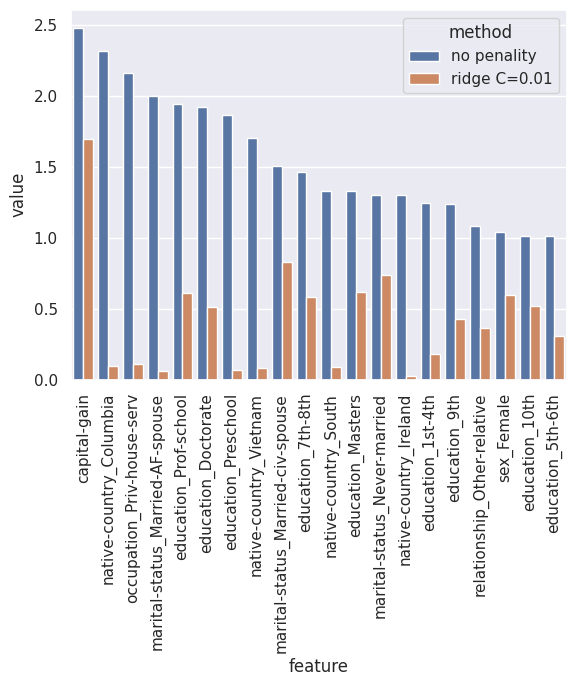

In [59]:
# On visualise l'effet de 'shrinkage'
ax = sns.barplot(data=pd.concat([df1, df2]), x="feature", y="value", hue="method")
ax.tick_params(axis='x', rotation=90)

In [60]:
# On évalue les performances sur les données de test
y_predicted_ridge = model_ridge.predict(x_test)

accuracy_ridge = model_ridge.score(x_test, y_test)
precision_ridge = precision_score(y_test, y_predicted_ridge)
recall_ridge = recall_score(y_test, y_predicted_ridge)

print(f"Precision score: {precision_ridge:.3f}")
print(f"Recall score: {recall_ridge:.3f}")

hat_p_ridge = model_ridge.predict_proba(x_test)
AUC_ridge = roc_auc_score(y_test, hat_p_ridge[:,1])

Precision score: 0.736
Recall score: 0.568


In [61]:
df_metrics = pd.DataFrame({'Model': ["No penality", "Ridge"],
                           'Accuracy' : [round(accuracy,3), round(accuracy_ridge,3)], 
                           'Recall' : [round(recall,3), round(recall_ridge,3)], 
                           'Precision' : [round(precision,3), round(precision_ridge,3)], 
                           'AUC' : [round(AUC_noPenalty,3), round(AUC_ridge,3)]})

df_metrics.set_index('Model', inplace=True)

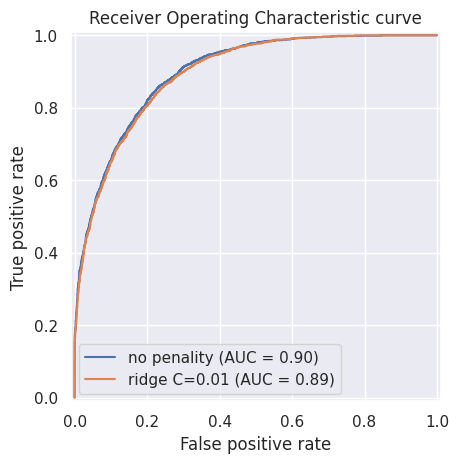

In [62]:
fig, ax = plt.subplots()
RocCurveDisplay.from_estimator(model, x_test, y_test, name="no penality", ax=ax)
RocCurveDisplay.from_estimator(model_ridge, x_test, y_test, name=f"ridge C={C_ridge}", ax=ax)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Receiver Operating Characteristic curve")
ax.legend()
plt.show()

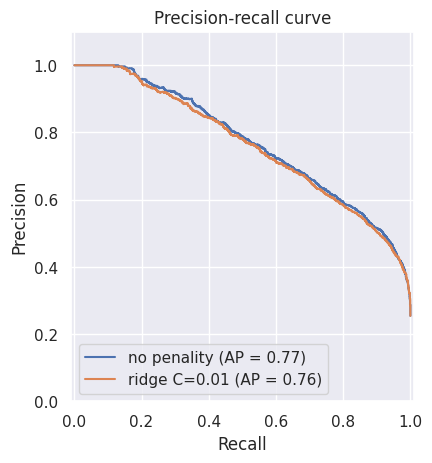

In [63]:
fig, ax = plt.subplots()
PrecisionRecallDisplay.from_estimator(model, x_test, y_test, name="no penality",ax=ax)
PrecisionRecallDisplay.from_estimator(model_ridge, x_test, y_test, name=f"ridge C={C_ridge}",ax=ax)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1.1)
ax.set_title("Precision-recall curve")
ax.legend()
plt.show()

## Régression lasso

Dans cette partie, on va mettre en oeuvre une pénalité $\ell_1$ dans la régression logistique. Cela peut permettre de faire de la sélection de variables : les variables peu informatives pour la prédiction ne seront plus du tout utilisées (coefficient $w_i$ estimé à 0). On peut ainsi construire un estimateur plus parcimonieux. 

### Exercice : pénalité $\ell_1$

- Mettre en oeuvre la régression logistique avec pénalité $\ell_1$ sur les données d'apprentissage (avec l'option `solver='liblinear'`).
- Comparer les valeurs des coefficients avec le cas sans pénalité et avec pénalité $\ell_2$ (visualiser l'effet d'annulation des coefficients). Tester différentes valeurs de $C$.
- Pour l'ensemble des classifieurs (avec et sans pénalisation $\ell_1$ et $\ell_2$), comparer les performances en termes de courbes (ROC et precision-recall) et d'AUC. 

### Solution

In [64]:
C_lasso = 0.01
model_lasso = LogisticRegression(l1_ratio=1, C=C_lasso, max_iter=1000, solver='liblinear')
model_lasso.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [65]:
print(f"Nombre de coefficients non nuls avec pénalité Lasso (C={C_lasso}):", np.sum(extract_coeff(model_lasso)["value"] > 0))

Nombre de coefficients non nuls avec pénalité Lasso (C=0.01): 22


In [66]:
df3 = extract_coeff(model_lasso, f"lasso C={C_lasso}")
df3 = df3[df3["feature"].isin(df1["feature"])]

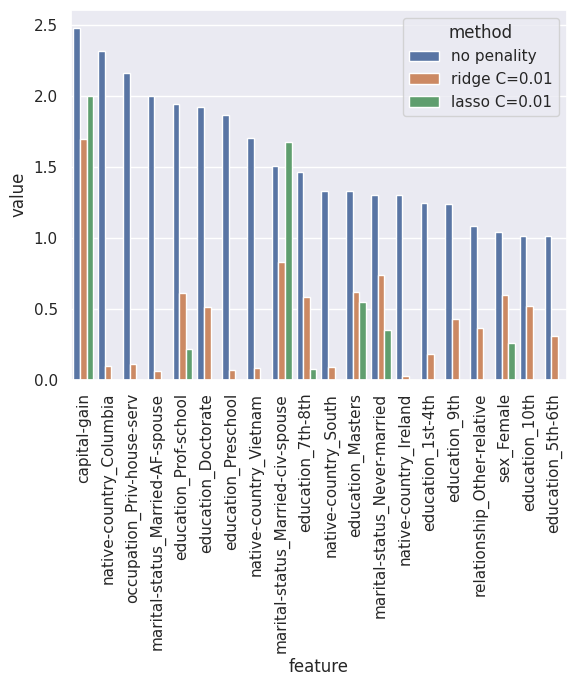

In [67]:
ax = sns.barplot(data=pd.concat([df1, df2, df3]), x="feature", y="value", hue="method")
ax.tick_params(axis='x', rotation=90)

In [68]:
y_predicted_lasso = model_lasso.predict(x_test)

accuracy_lasso = model_lasso.score(x_test, y_test)
precision_lasso = precision_score(y_test, y_predicted_lasso)
recall_lasso = recall_score(y_test, y_predicted_lasso)
hat_p_lasso = model_lasso.predict_proba(x_test)
AUC_lasso = roc_auc_score(y_test, hat_p_lasso[:,1])

df_metrics.loc['Lasso',:] = [round(accuracy_lasso,3),
                             round(recall_lasso,3),
                             round(precision_lasso,3),
                             round(AUC_lasso,3)]
df_metrics

,Accuracy,Recall,Precision,AUC
Model,,,,
No penality,0.841,0.609,0.722,0.898
Ridge,0.838,0.568,0.736,0.894
Lasso,0.830,0.540,0.723,0.884


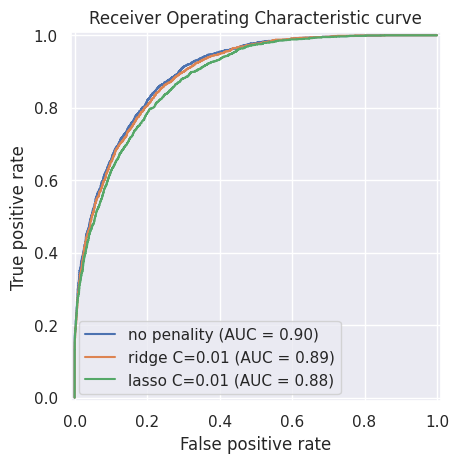

In [69]:
fig, ax = plt.subplots()
RocCurveDisplay.from_estimator(model, x_test, y_test, name="no penality", ax=ax)
RocCurveDisplay.from_estimator(model_ridge, x_test, y_test, name=f"ridge C={C_ridge}", ax=ax)
RocCurveDisplay.from_estimator(model_lasso, x_test, y_test, name=f"lasso C={C_lasso}", ax=ax)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Receiver Operating Characteristic curve")
ax.legend()
plt.show()

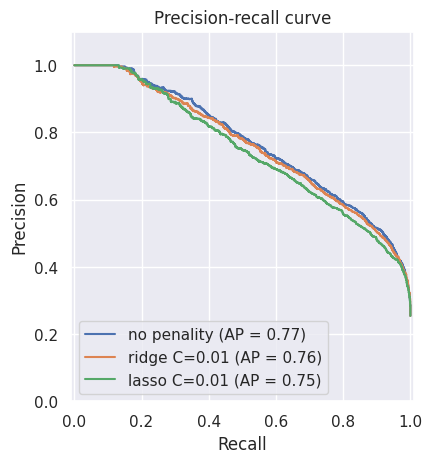

In [70]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots()
PrecisionRecallDisplay.from_estimator(model, x_test, y_test, name="no penality", ax=ax)
PrecisionRecallDisplay.from_estimator(model_ridge, x_test, y_test, name=f"ridge C={C_ridge}", ax=ax)
PrecisionRecallDisplay.from_estimator(model_lasso, x_test, y_test, name=f"lasso C={C_lasso}", ax=ax)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1.1)
ax.set_title("Precision-recall curve")
ax.legend()
plt.show()

### Chemins de régularisation pour le Lasso

Le but est de visualiser l'effet de la **constante de pénalisation** sur l'évolution des coefficients $w_i$, à travers les **chemins de régularisation**. Lorsque la pénalité est très forte (i.e $C$ très petite), aucune  variable n'est sélectionnée (tous les coefficients $w_i$ sont estimés à 0). Dans ce cas, la fonction de régression logistique est constante (on a seulement l'intercept) et le lien entre $y$ et $X$ est très mal appris. Puis au fur et à mesure que $C$ augmente, on inclue de plus en plus de variables dans notre modèle de régression logistique. Lorsque $C$ est très grande, on ne pénalise plus et on retrouve les résultats de la régression logistique simple. 

### Exercice : évolution des coéfficients en fonction de $C$

- Fixer une grille de valeurs de $C$, estimer le modèle lasso pour chaque constante $C$ et afficher les coefficients en fonction de $C$. 

### Solution

In [71]:
%%time
n_grid = 13
n_coef = model.coef_.shape[1]
C_grid = np.logspace(-4, 1, n_grid)
coefs = np.empty((n_grid, n_coef))
for k, C in enumerate(C_grid): 
    model_ = LogisticRegression(l1_ratio=1, C=C, max_iter=1000, solver='liblinear')
    model_.fit(x_train, y_train)
    coefs[k] = model_.coef_

CPU times: user 13.5 s, sys: 172 ms, total: 13.7 s
Wall time: 13.7 s


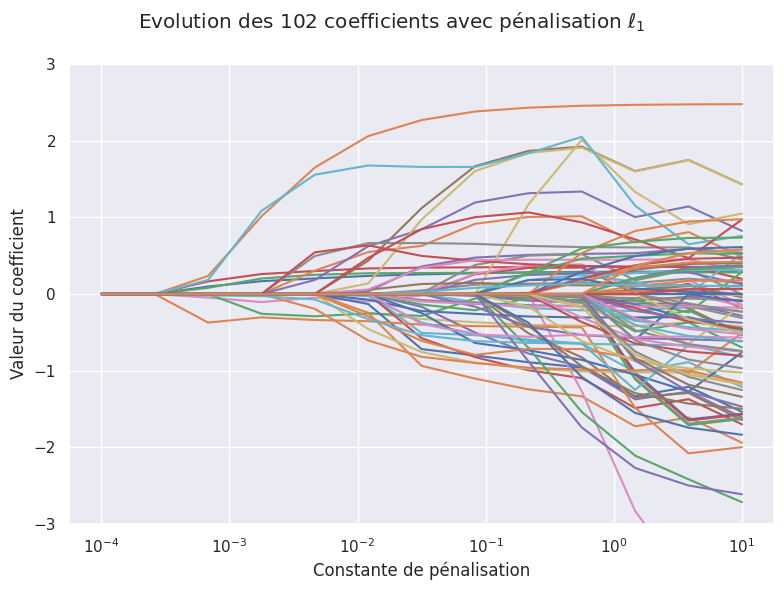

In [72]:
fig, ax = plt.subplots(figsize=(8,6), layout="tight")
ax.semilogx(C_grid, coefs)
ax.set_ylim(-3, 3)
ax.set_xlabel("Constante de pénalisation")
ax.set_ylabel("Valeur du coefficient")
fig.suptitle(fr"Evolution des {n_coef} coefficients avec pénalisation $\ell_1$")
plt.show()

# Validation croisée

La validation croisée consiste à entrainer le modèle sur différents sous-échantillons des données et d'évaluer à chaque fois sa capacité prédictive sur le reste des données. 
La validation croisée permet de choisir la meilleure constante $C$ de la pénalité Lasso ou Ridge. Plus généralement, dans de nombreux autres modèles, la validation croisée est utilisée pour ajuster les hyperparamètres du modèle de façon optimale en évitant le surapprentissage et augmentant sa capacité de généralisation sur des nouvelles données.

## Exercice :  Stabilité des prédictions

- Utiliser la fonction `cross_validate` du module `sklearn.model_selection` pour obtenir un intervale de confiance de l'accuracy score. On fera cette étude sur le modèle de régression logistique simple `model` et celui avec pénalité $\ell_1$ `model_lasso`.

## Solution

In [73]:
%%time
from sklearn.model_selection import cross_validate

cv_results = cross_validate(model, standard_data, labels, cv=8)
cv_results

CPU times: user 2min 40s, sys: 241 ms, total: 2min 40s
Wall time: 21.4 s


{'fit_time': array([3.36231875, 3.09169269, 3.02099299, 2.50072598, 2.24103236,
        2.18499231, 2.32083893, 2.50176048]),
 'score_time': array([0.0235827 , 0.02321172, 0.03101826, 0.01398373, 0.01070166,
        0.01055717, 0.01419544, 0.02591586]),
 'test_score': array([0.83710499, 0.84444444, 0.84138634, 0.84342508, 0.84689093,
        0.83649337, 0.84057085, 0.84077472])}

In [74]:
scores = cv_results["test_score"]
print("The mean cross-validation accuracy is: "
      f"{scores.mean():.3f} ± {scores.std():.3f}")

The mean cross-validation accuracy is: 0.841 ± 0.003


In [75]:
%%time
from sklearn.model_selection import cross_validate

cv_results = cross_validate(model_lasso, standard_data, labels, cv=8)
cv_results

CPU times: user 6.31 s, sys: 103 ms, total: 6.41 s
Wall time: 2 s


{'fit_time': array([0.2431488 , 0.24311185, 0.23558497, 0.2295754 , 0.24104309,
        0.24631333, 0.24500775, 0.2389667 ]),
 'score_time': array([0.0060389 , 0.00604916, 0.00610828, 0.00595903, 0.0058341 ,
        0.00602603, 0.00781775, 0.0127871 ]),
 'test_score': array([0.8332314 , 0.8285423 , 0.83527013, 0.83282365, 0.83955148,
        0.82833843, 0.8293578 , 0.83037717])}

In [76]:
scores = cv_results["test_score"]
print("The mean cross-validation accuracy is: "
      f"{scores.mean():.3f} ± {scores.std():.3f}")

The mean cross-validation accuracy is: 0.832 ± 0.004


## Choix de la constante de pénalisation

On peut aussi utiliser la validation croisée pour choisir un hyperparamètre. Dans cette partie, nous allons mettre en oeuvre le choix de la constante de pénalisation par **validation croisée**. 
Nous le ferons dans le cadre d'une pénalité $\ell_1$, mais on pourrait faire exactement la même chose avec un autre type de pénalité. 

Par défaut, la fonction `LogisticRegression` ne sait pas choisir la constante de pénalisation automatiquement et par défaut cette constante est fixée à 1. Ce choix n'a pas de justification et n'a donc aucune raison d'être utilisé. 

## Exercice : validation croisée

- Utiliser la fonction `LogisticRegressionCV` pour choisir la constante $C$ qui maximise le score AUC (aire sous la courbe ROC) dans une grille de valeur de $C$ fixée.

## Solution

In [77]:
%%time
from sklearn.linear_model import LogisticRegressionCV

C_grid = np.logspace(-4, 1, 14)
cv = 8

# Modèle de régression logistique avec pénalité l1 
# validation croisée pour le choix automatique de la constante de pénalité C
model_lasso_cv = LogisticRegressionCV(penalty='l1', tol=1e-3, Cs=C_grid, cv=8,
                                      solver='liblinear', scoring='roc_auc') 
model_lasso_cv.fit(x_train, y_train)

# résultats intermédiaires de calculs de ROC-AUC sur chacun des cv-folds
crit = model_lasso_cv.scores_[1]
print(crit)

[[0.5        0.5        0.78911771 0.85389319 0.87374767 0.88394407
  0.8941403  0.8992635  0.90057114 0.90127281 0.90154129 0.9017156
  0.90159471 0.9014728 ]
 [0.5        0.5        0.79674284 0.86270079 0.87887686 0.8870487
  0.89570837 0.89860873 0.89907566 0.89893303 0.89830858 0.89721172
  0.8969631  0.89689803]
 [0.5        0.5        0.79095049 0.85628451 0.87300901 0.88218097
  0.89445449 0.89965954 0.90135431 0.90217431 0.90237669 0.90236505
  0.9024195  0.9024808 ]
 [0.5        0.5        0.79586617 0.85643519 0.87550819 0.8835571
  0.89432094 0.89925048 0.90083653 0.90143582 0.90129524 0.90127607
  0.90121614 0.90115552]
 [0.5        0.5        0.78302023 0.85221294 0.87120038 0.88064946
  0.89193769 0.89524056 0.89558803 0.89683674 0.8968806  0.89673479
  0.89663301 0.89657613]
 [0.5        0.5        0.79129976 0.86042463 0.88265    0.89320935
  0.90378327 0.90809771 0.90945368 0.91028689 0.91067651 0.91075019
  0.91073751 0.91066555]
 [0.5        0.5        0.7910592  0.

Text(0.5, 0.98, 'Cross validation scores for Lasso penality')

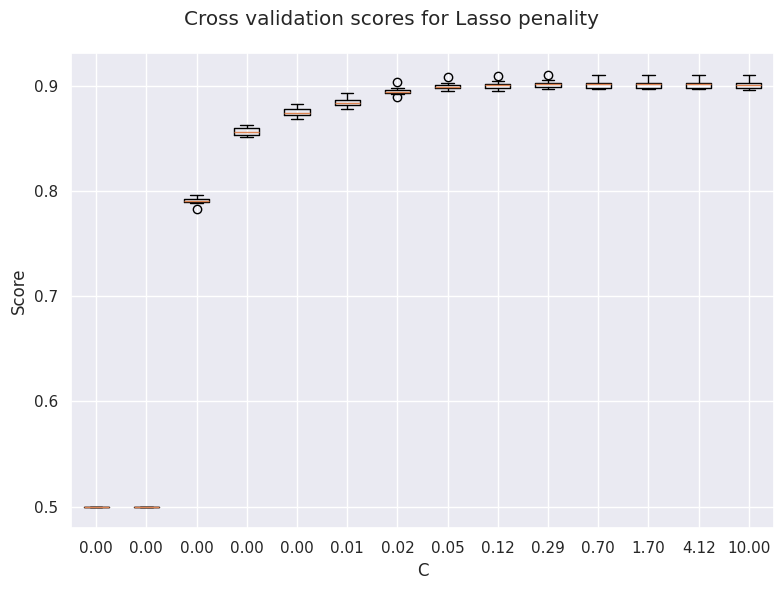

In [78]:
fig, ax = plt.subplots(figsize=(8,6), layout="tight")
ax.set_ylabel("Score")
ax.set_xlabel("C")
ax.boxplot(crit, tick_labels=[f"{x:.2f}" for x in C_grid])

fig.suptitle("Cross validation scores for Lasso penality")


In [79]:
np.mean(crit, axis=0)

array([0.5       , 0.5       , 0.79096441, 0.85673746, 0.87507317,
       0.88440251, 0.89520189, 0.89971734, 0.90096822, 0.90172637,
       0.90180007, 0.90167274, 0.90157669, 0.90149151])

In [80]:
print("La valeur de C 'optimale' avec pénalité lasso est: ", model_lasso_cv.C_[0])

La valeur de C 'optimale' avec pénalité lasso est:  0.701703828670383


In [81]:
y_predicted_lasso_cv = model_lasso_cv.predict(x_test)

accuracy_lasso_cv = model_lasso_cv.score(x_test, y_test)

precision_lasso_cv = precision_score(y_test, y_predicted_lasso_cv)
recall_lasso_cv = recall_score(y_test, y_predicted_lasso_cv)

hat_p_lasso_cv = model_lasso_cv.predict_proba(x_test)
AUC_lasso_cv = roc_auc_score(y_test, hat_p_lasso_cv[:,1])

df_metrics.loc["Lasso-CV",:] = [round(accuracy_lasso_cv,3),
                                  round(recall_lasso_cv,3),
                                  round(precision_lasso_cv,3),
                                  round(AUC_lasso_cv,3)]

df_metrics

,Accuracy,Recall,Precision,AUC
Model,,,,
No penality,0.841,0.609,0.722,0.898
Ridge,0.838,0.568,0.736,0.894
Lasso,0.830,0.540,0.723,0.884
Lasso-CV,0.899,0.608,0.721,0.899


# `scikit-learn` et automatisation: `pipeline`

En `scikit-learn`, un _pipeline_ est une séquence ordonnée d'étapes de prétraitement des données et de modélisation regroupées en une seule entité. Il permet de définir et d'automatiser un flux de travail cohérent pour le traitement des données et l'entraînement d'un modèle.

Il se compose en général de plusieurs étapes:
- transformations des données :  normalisation des variables, l'imputation des valeurs manquantes, la réduction de dimension, etc. Elles permettent de préparer les données avant de les fournir au modèle.
- le modèle d'apprentissage automatique.
- la validation croisée : pour évaluer les performances du modèle.

L'avantage d'utiliser un pipeline est qu'il permet de regrouper toutes ces étapes en une seule entité. 

## Exercice : Création d'un pipeline pour notre régression logistique 

- Définir à partir des classes `OneHotEncoder`, `StandardScaler` de `sklearn.preprocessing` et `ColumnTransformer` de `sklearn.compose` un préprocesseur qui réalise les mêmes transformations que celles faites dans la section 1.1.5 (Pré-traitement des données). Attention, la transformation `OneHotEncoder` doit s'appliquer uniquement aux données qualitatives et la transformation `StandardScaler` doit s'appliquer uniquement aux données quantitatives. 
- Créer un pipeline avec la fonction `make_pipeline` de `sklearn.pipeline` pour définir un modèle de régression logistique avec prétraitement des données automatique (fait par le préprocesseur).

## Solution

In [82]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

quantitative_preprocessor = StandardScaler()
qualitative_preprocessor = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer([
    ('standard_scaler', quantitative_preprocessor, quantitative.columns),
    ('one-hot-encoder', qualitative_preprocessor, qualitative.columns)
])

model_pipe = make_pipeline(preprocessor, LogisticRegression(penalty=None, max_iter=1000))
model_pipe 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standard_scaler', ...), ('one-hot-encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If t

## Exercice : Utilisation du pipeline 

- Faire une estimation du modèle. Attention, quelles données doivent être utilisées ?
- Faire des prédictions et calculer les différents scores sur le jeu de test.
- Faire une étape de validation croisée. 

## Solution

In [83]:
# on retravaille à partir des données avant prétraitement 
from sklearn.model_selection import train_test_split
data = pd.concat([quantitative, qualitative], axis=1)

x_train, x_test, y_train, y_test = train_test_split(data, labels,  stratify=labels,
                                                    test_size = 0.2, random_state = 42)

In [39]:
model_pipe.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standard_scaler', ...), ('one-hot-encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If t

In [84]:
model_pipe.named_steps['logisticregression'].intercept_

AttributeError: 'LogisticRegression' object has no attribute 'intercept_'

In [ ]:
model_pipe.named_steps['logisticregression'].intercept_

In [ ]:
model_pipe.named_steps['logisticregression'].coef_

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
y_predicted = model_pipe.predict(x_test)

accuracy_pipe = accuracy_score(y_test, y_predicted) # ou model_pipe.score(x_test, y_test)
precision_pipe = precision_score(y_test, y_predicted)
recall_pipe = recall_score(y_test, y_predicted)

hat_p_pipe = model_pipe.predict_proba(x_test)
AUC_pipe = roc_auc_score(y_test, hat_p_pipe[:,1])

df_metrics.loc['Pipeline',:] = [round(accuracy_pipe,3),
                                  round(recall_pipe,3),
                                  round(precision_pipe,3),
                                  round(AUC_pipe,3)]

df_metrics

In [ ]:
cv_results = cross_validate(model_pipe, data, labels, cv=5)
cv_results

In [ ]:
scores = cv_results["test_score"]
print("The mean cross-validation accuracy is: "
      f"{scores.mean():.3f} ± {scores.std():.3f}")

## Exercice : Avec une autre méthode de classification : Gradient Boosting

L'avantage d'utiliser un module riche comme `scikit-learn` est qu'on peut facilement changer une brique pour tester d'autres modèles. Ici on propose de remplacer la brique `LogisticRegression` par une méthode basée sur les arbres de décisions. Les arbres de décisions et les méthodes de "boosting" seront expliquées dans le second cours mais voyons les résultats que l'on peut obtenir. 

- Utiliser le préprocesseur `OneHotEncoder` avec l'option `sparse_output` à `False` et la classe `HistGradientBoostingClassifier` du module `sklearn.ensemble` pour composer un pipeline que l'on nomme `model_gradboost`.

- Comparer les courbes ROC et Precision/Recall obtenues avec cet estimateur et la régression logistique. 

## Solution

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

quantitative_preprocessor = StandardScaler()
qualitative_preprocessor = OneHotEncoder(handle_unknown="ignore", 
                                         sparse_output=False)

preprocessor = ColumnTransformer([
    ('standard_scaler', quantitative_preprocessor, quantitative.columns),
    ('ordinal-encoder', qualitative_preprocessor, qualitative.columns)],
)

model_gradboost = make_pipeline(preprocessor, HistGradientBoostingClassifier())
model_gradboost.fit(x_train, y_train)

**Remarque:** dans la [documentation officielle](https://scikit-learn.org/stable/auto_examples/ensemble/plot_gradient_boosting_categorical.html#sphx-glr-auto-examples-ensemble-plot-gradient-boosting-categorical-py) il est conseillé d'utiliser un autre préprocesseur pour les données qualitatives. Il s'agit de l'encodage `OrdinalEncoder`. Par cohérence avec la régression logistique on garde le `OneHotEncoder`.

In [ ]:
y_predicted = model_gradboost.predict(x_test)

accuracy_gradboost = accuracy_score(y_test, y_predicted) # ou model_gradboost.score(x_test, y_test)
precision_gradboost = precision_score(y_test, y_predicted)
recall_gradboost = recall_score(y_test, y_predicted)

hat_p_gradboost = model_gradboost.predict_proba(x_test)
AUC_gradboost = roc_auc_score(y_test, hat_p_gradboost[:,1])

df_metrics.loc['Grad boost',:] = [round(accuracy_gradboost,3),
                                  round(recall_gradboost,3),
                                  round(precision_gradboost,3),
                                  round(AUC_gradboost,3)]

df_metrics

In [ ]:
fig, ax = plt.subplots()
RocCurveDisplay.from_estimator(model_pipe, x_test, y_test, 
                               name="Logistic Regression", ax=ax)
RocCurveDisplay.from_estimator(model_gradboost, x_test, y_test, 
                               name="Gradient Boosting", ax=ax)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Receiver Operating Characteristic curve on Test set")
ax.legend()
plt.show()

In [ ]:
fig, ax = plt.subplots()
PrecisionRecallDisplay.from_estimator(model_pipe, x_test, y_test, 
                                      name="Logistic Regression", ax=ax)
PrecisionRecallDisplay.from_estimator(model_gradboost, x_test, y_test, 
                                      name="Gradient Boosting", ax=ax)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1.1)
ax.set_title("Precision-recall curve on Test set")
ax.legend()
plt.show()